In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from marine_qc import (
    Climatology,
    do_bayesian_buddy_check,
    do_multiple_grouped_check,
    latitude_longitude_plot,
    latitude_variable_plot,
)

In [3]:
from examples.data import get_climatology_data, get_grouped_data

C:\Users\llierham\mobaxterm\.venvs\mp_py\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# How to use quality control checks with grouped reports

We need some text!!!

In [4]:
data = get_grouped_data()
data

,platform,date,lat,lon,sst
0,ship_001,2026-07-01 12:00:00,45.000914,-30.003120,19.612568
1,ship_001,2026-07-01 13:00:00,45.002822,-30.005853,19.477878
2,ship_001,2026-07-01 14:00:00,45.000384,-30.000949,19.670685
3,ship_001,2026-07-01 15:00:00,44.997441,-29.997362,19.616669
4,ship_001,2026-07-01 16:00:00,45.000198,-29.996618,19.396921
5,ship_001,2026-07-01 17:00:00,44.997422,-29.998894,19.182963
6,ship_002,2026-07-01 12:00:00,45.020635,-29.982150,19.472271
7,ship_002,2026-07-01 13:00:00,45.015957,-29.978332,19.650026
8,ship_002,2026-07-01 14:00:00,45.016715,-29.983056,19.753051
9,ship_002,2026-07-01 15:00:00,45.019096,-29.980762,19.564623


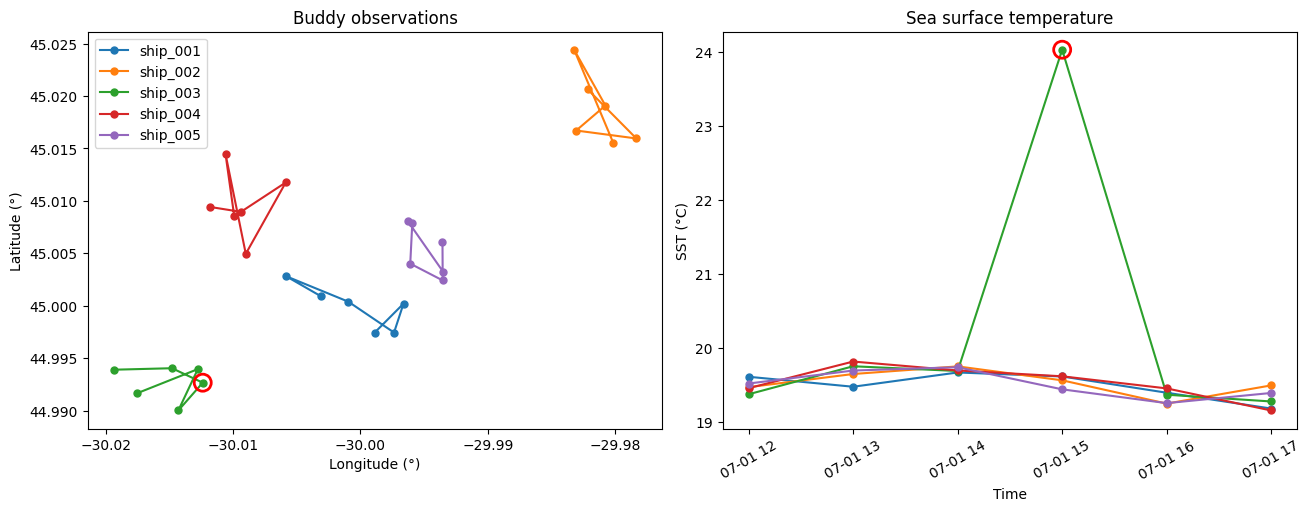

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# consistent colors for each platform
colors = plt.cm.tab10.colors

for color, (platform, group) in zip(colors, data.groupby("platform")):
    ax1.plot(
        group["lon"],
        group["lat"],
        "-o",
        ms=5,
        label=platform,
        color=color,
    )

    ax2.plot(
        group["date"],
        group["sst"],
        "-o",
        ms=5,
        label=platform,
        color=color,
    )

# highlight the injected outlier
outlier = data.loc[(data.platform == "ship_003") & (data.date == pd.Timestamp("2026-07-01 15:00"))]

ax1.scatter(
    outlier.lon,
    outlier.lat,
    s=150,
    facecolors="none",
    edgecolors="red",
    linewidth=2,
    zorder=10,
)

ax2.scatter(
    outlier.date,
    outlier.sst,
    s=150,
    facecolors="none",
    edgecolors="red",
    linewidth=2,
    zorder=10,
)

ax1.set_xlabel("Longitude (°)")
ax1.set_ylabel("Latitude (°)")
ax1.set_title("Buddy observations")
ax1.legend(loc="best")

ax2.set_xlabel("Time")
ax2.set_ylabel("SST (°C)")
ax2.set_title("Sea surface temperature")
ax2.tick_params(axis="x", rotation=30)

plt.show()

In [6]:
climatology_data = get_climatology_data()
climatology_data

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 1, latitude: 180, longitude: 360)
Coordinates:
  * time           (time) datetime64[us] 8B 2026-07-01T12:00:00
  * latitude       (latitude) int64 1kB -90 -89 -88 -87 -86 ... 85 86 87 88 89
  * longitude      (longitude) int64 3kB -180 -179 -178 -177 ... 176 177 178 179
Data variables:
    land_sea_mask  (time, latitude, longitude) int8 65kB 1 1 1 1 1 ... 0 0 0 0 0
    sst            (time, latitude, longitude) float64 518kB nan nan ... 0.04343
    sst_stdev1     (time, latitude, longitude) float64 518kB nan nan ... 0.4754
    sst_stdev2     (time, latitude, longitude) float64 518kB nan nan ... 0.8407
    sst_stdev3     (time, latitude, longitude) float64 518kB nan nan ... 0.2352
    crs            int64 8B 0

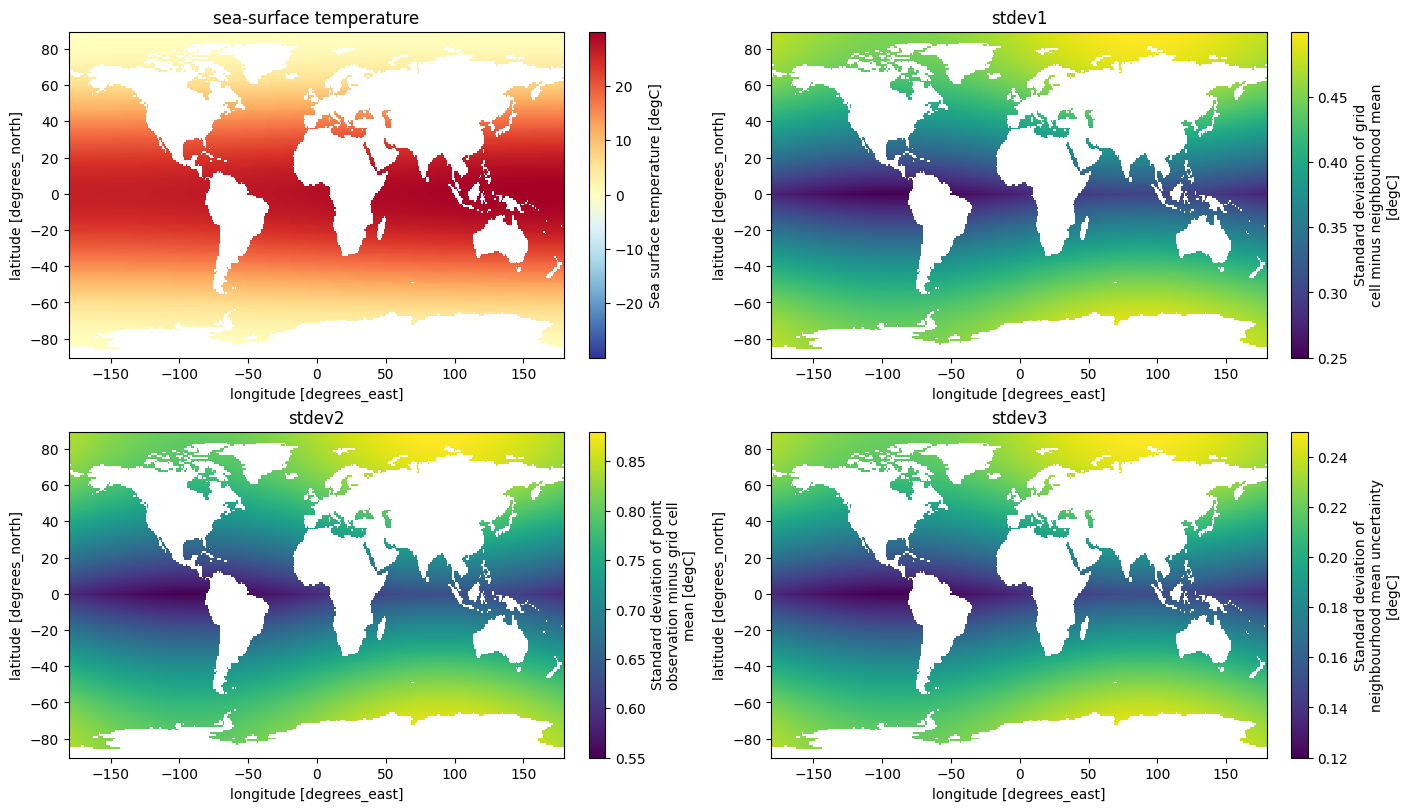

In [7]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8),
    constrained_layout=True,
)

plots = [
    ("sst", "sea-surface temperature", "RdYlBu_r"),
    ("sst_stdev1", "stdev1", "viridis"),
    ("sst_stdev2", "stdev2", "viridis"),
    ("sst_stdev3", "stdev3", "viridis"),
]

for ax, (var, title, cmap) in zip(axes.flat, plots):
    climatology_data[var].isel(time=0).plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=True,
    )
    ax.set_title(title)

plt.show()

In [8]:
sst_stdev1 = Climatology(climatology_data.sst_stdev1)
sst_stdev2 = Climatology(climatology_data.sst_stdev2)
sst_stdev3 = Climatology(climatology_data.sst_stdev3)

In [9]:
qc_bayesian_buddy_check = do_bayesian_buddy_check(
    value=data.sst,
    lat=data.lat,
    lon=data.lon,
    date=data.date,
    climatology=climatology_data.sst,
    stdev1=sst_stdev1,
    stdev2=sst_stdev2,
    stdev3=sst_stdev3,
    prior_probability_of_gross_error=0.05,
    quantization_interval=0.1,
    one_sigma_measurement_uncertainty=1.0,
    limits=[2, 2, 4],
    noise_scaling=3.0,
    maximum_anomaly=8.0,
    fail_probability=0.3,
)
qc_bayesian_buddy_check

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    1
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
dtype: int64

In [10]:
qc_dict = {
    "bayesian_buddy_check": {
        "func": "do_bayesian_buddy_check",
        "names": {
            "value": "sst",
            "lat": "lat",
            "lon": "lon",
            "date": "date",
        },
        "arguments": {
            "climatology": climatology_data.sst,
            "stdev1": sst_stdev1,
            "stdev2": sst_stdev2,
            "stdev3": sst_stdev3,
            "prior_probability_of_gross_error": 0.05,
            "quantization_interval": 0.1,
            "one_sigma_measurement_uncertainty": 1.0,
            "limits": [2, 2, 4],
            "noise_scaling": 3.0,
            "maximum_anomaly": 8.0,
            "fail_probability": 0.3,
        },
    },
    "mds_buddy_check": {
        "func": "do_mds_buddy_check",
        "names": {
            "value": "sst",
            "lat": "lat",
            "lon": "lon",
            "date": "date",
        },
        "arguments": {
            "climatology": climatology_data.sst,
            "standard_deviation": sst_stdev1,
            "limits": [[1, 1, 2], [2, 2, 2], [1, 1, 4], [2, 2, 4]],
            "number_of_obs_thresholds": [[0, 5, 15, 100], [0], [0, 5, 15, 100], [0]],
            "multipliers": [[4.0, 3.5, 3.0, 2.5], [4.0], [4.0, 3.5, 3.0, 2.5], [4.0]],
        },
    },
}
do_multiple_grouped_check(
    data,
    qc_dict=qc_dict,
)

,bayesian_buddy_check,mds_buddy_check
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


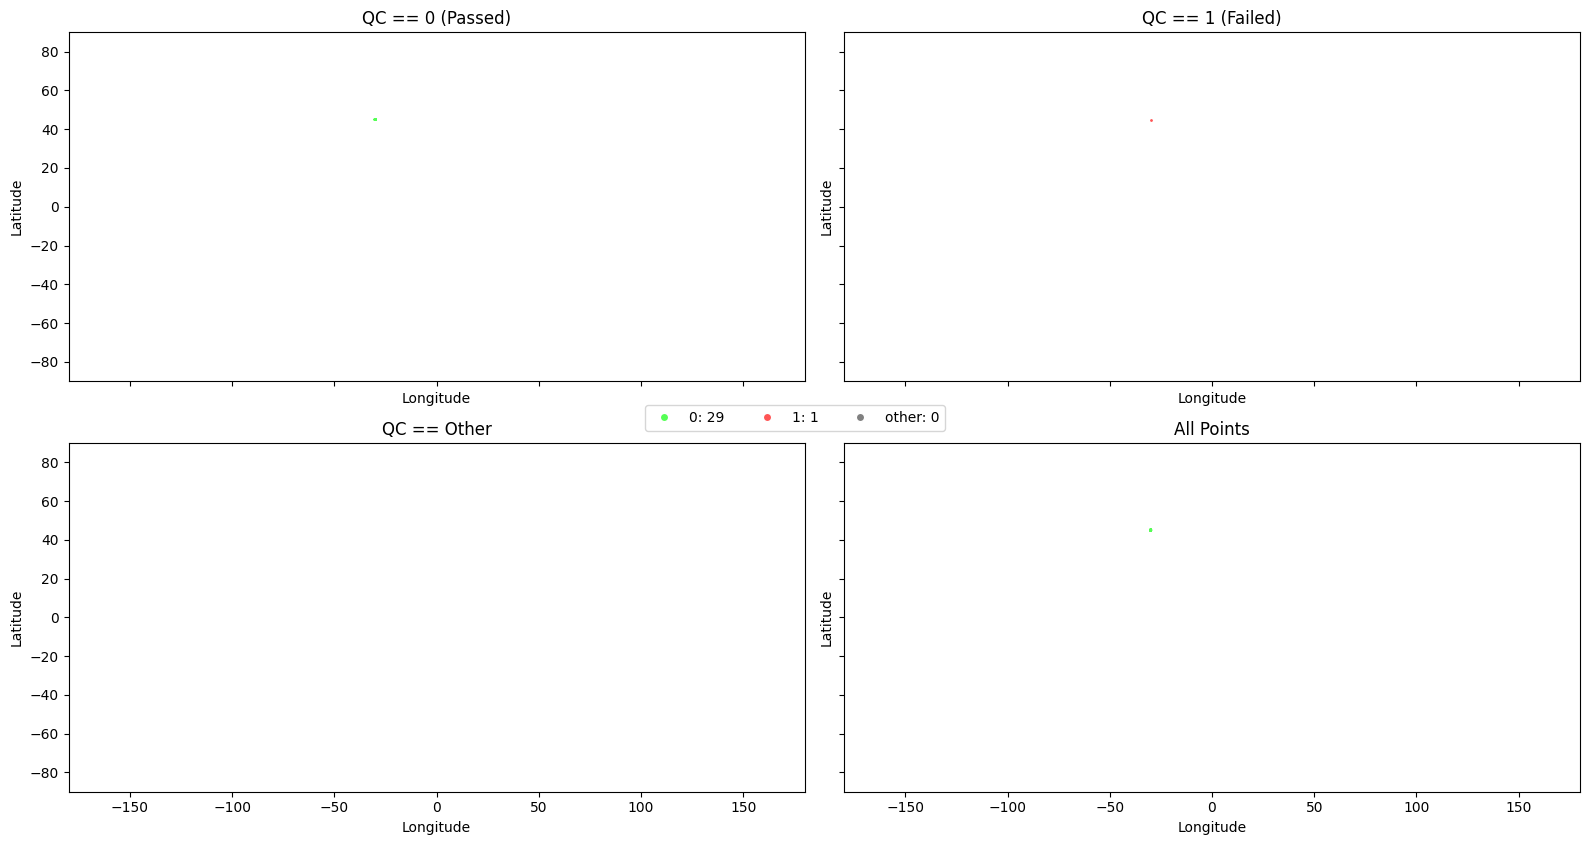

In [11]:
lat_lon_plot = latitude_longitude_plot(
    lat=data.lat,
    lon=data.lon,
    qc_outcomes=qc_bayesian_buddy_check,
)

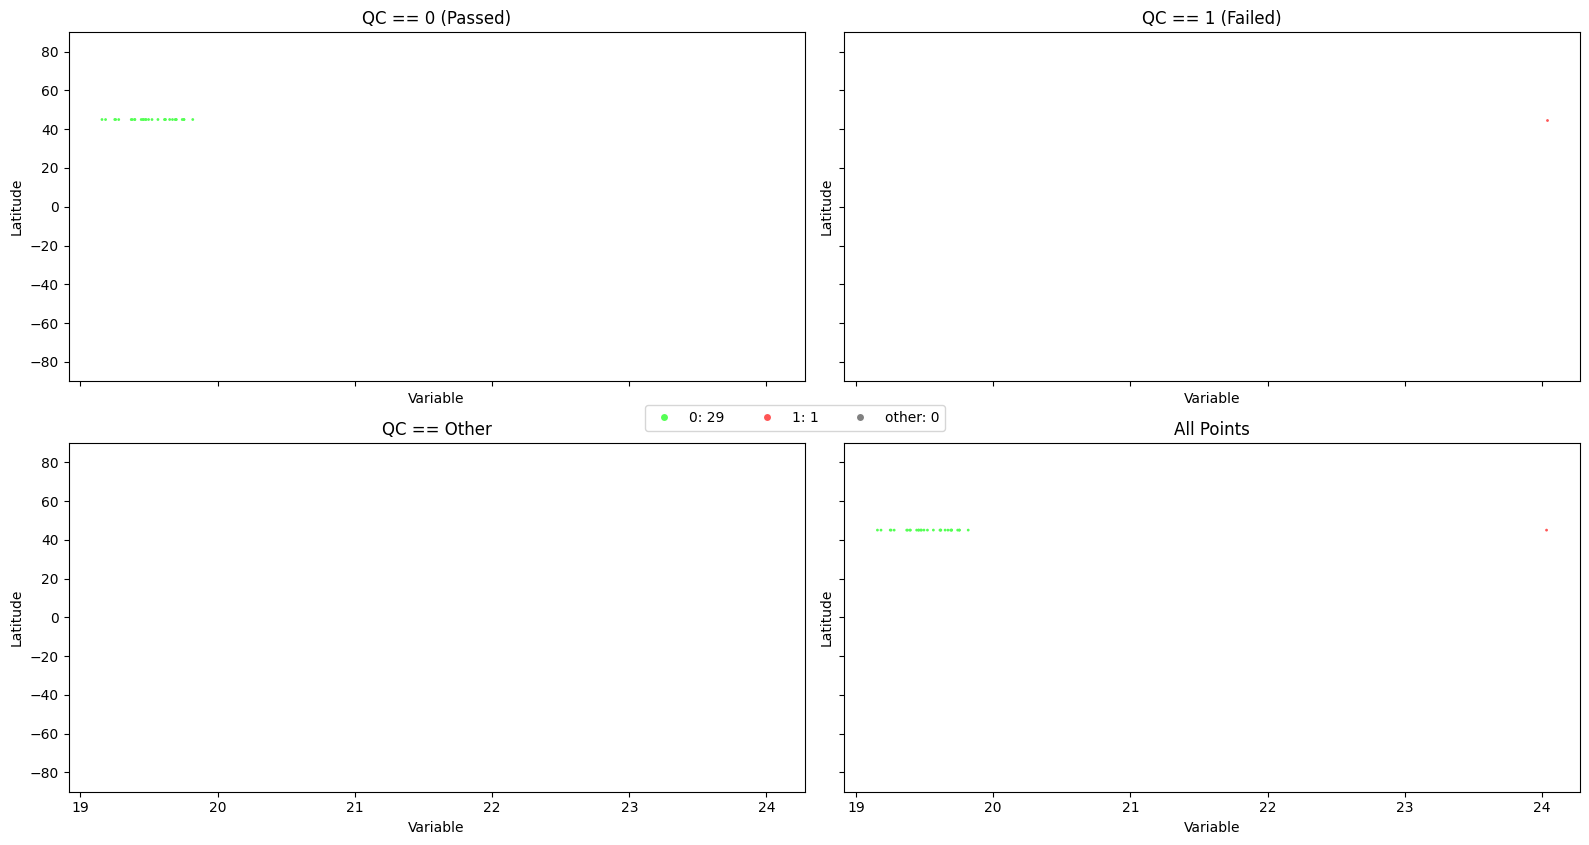

In [12]:
lat_var_plot = latitude_variable_plot(
    lat=data.lat,
    value=data.sst,
    qc_outcomes=qc_bayesian_buddy_check,
)